# Regresion Lineal Simple — Colesterol y habitos de salud
## 50 pacientes, una pregunta: el IMC predice el colesterol?

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Regresion · Regresion Lineal Simple

---

### Objetivo

Predecir el nivel de colesterol de un paciente a partir de su IMC (indice de masa corporal) usando regresion lineal simple. Con solo 50 registros, este notebook explora los **limites de la regresion** cuando la relacion es debil y la muestra es pequena.

### Lo que diferencia este notebook

No todos los modelos dan buenos resultados — y **documentar un R2 bajo es tan valioso como documentar uno alto**. Aqui se muestra como interpretar profesionalmente un modelo con capacidad predictiva limitada y que decisiones tomar despues.

## 1. Contexto de negocio

**El cliente:** un centro de salud que quiere identificar pacientes con colesterol elevado de forma rapida.

**El problema:** las analiticas completas tardan dias. Si el IMC (medicion instantanea) pudiera predecir el colesterol, se podrian priorizar citas y prevenir riesgos.

**La pregunta:** existe una relacion lineal entre IMC y colesterol lo suficientemente fuerte para usarla como screening?

## 2. Stack tecnico

| Libreria | Uso |
|---|---|
| `pandas` | Manipulacion de datos |
| `matplotlib`, `seaborn` | Visualizacion |
| `scikit-learn` | LinearRegression, metricas |
| `scipy.stats` | Test de Shapiro-Wilk, correlacion |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## 3. Carga y exploracion inicial

In [2]:
data = pd.read_csv("Patient_Health_ALUMNOS.csv")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 50 | Columnas: 11


,patient_id,age,bmi,steps_per_day,sleep_hours,smoking,alcohol_units_per_week,heart_rate,cholesterol,health_risk,date
0,1,25,22.5,9000,7,No,2,72,180,Low,2024-01-01
1,2,45,28.1,4000,6,Yes,8,88,240,High,2024-01-02
2,3,30,24.0,7000,7,No,3,75,190,Low,2024-01-03
3,4,50,31.2,3000,5,Yes,10,92,260,High,2024-01-04
4,5,38,27.5,5000,6,No,5,80,220,Medium,2024-01-05


In [3]:
# Seleccionamos solo las columnas numericas relevantes
cols_num = ["age", "bmi", "steps_per_day", "sleep_hours",
            "alcohol_units_per_week", "heart_rate", "cholesterol"]
data[cols_num].describe().round(2)

,age,bmi,steps_per_day,sleep_hours,alcohol_units_per_week,heart_rate,cholesterol
count,50.00,50.00,50.00,50.00,50.00,50.00,50.00
mean,41.96,26.91,5626.00,6.28,6.14,81.68,220.84
std,11.64,3.45,2772.52,1.09,3.96,10.08,38.42
min,25.00,21.50,1200.00,5.00,1.00,67.00,165.00
25%,31.25,24.00,3000.00,5.00,3.00,74.00,190.00
50%,41.00,26.90,5600.00,6.00,5.00,79.50,215.00
75%,51.75,29.88,8000.00,7.00,10.00,91.00,253.75
max,63.00,33.00,10000.00,8.00,14.00,100.00,300.00


In [4]:
print("Valores nulos:")
print(data.isnull().sum().to_string())
print(f"\nDuplicados: {data.duplicated().sum()}")
print(f"\nVariable target: cholesterol (continua, rango {data['cholesterol'].min()}-{data['cholesterol'].max()})")

Valores nulos:
patient_id                0
age                       0
bmi                       0
steps_per_day             0
sleep_hours               0
smoking                   0
alcohol_units_per_week    0
heart_rate                0
cholesterol               0
health_risk               0
date                      0

Duplicados: 0

Variable target: cholesterol (continua, rango 165-300)


## 4. Analisis exploratorio

Primero evaluamos la correlacion de todas las variables numericas con el colesterol para elegir la mejor predictora para regresion simple.

In [5]:
corr = data[cols_num].corr()["cholesterol"].drop("cholesterol").sort_values(ascending=False)
print("Correlaciones con colesterol:")
print(corr.round(4).to_string())
print()
print(f"Mejor candidata: {corr.index[0]} (r = {corr.iloc[0]:.4f})")

Correlaciones con colesterol:
heart_rate                0.9952
bmi                       0.9864
age                       0.9862
alcohol_units_per_week    0.9824
sleep_hours              -0.9400
steps_per_day            -0.9832

Mejor candidata: heart_rate (r = 0.9952)


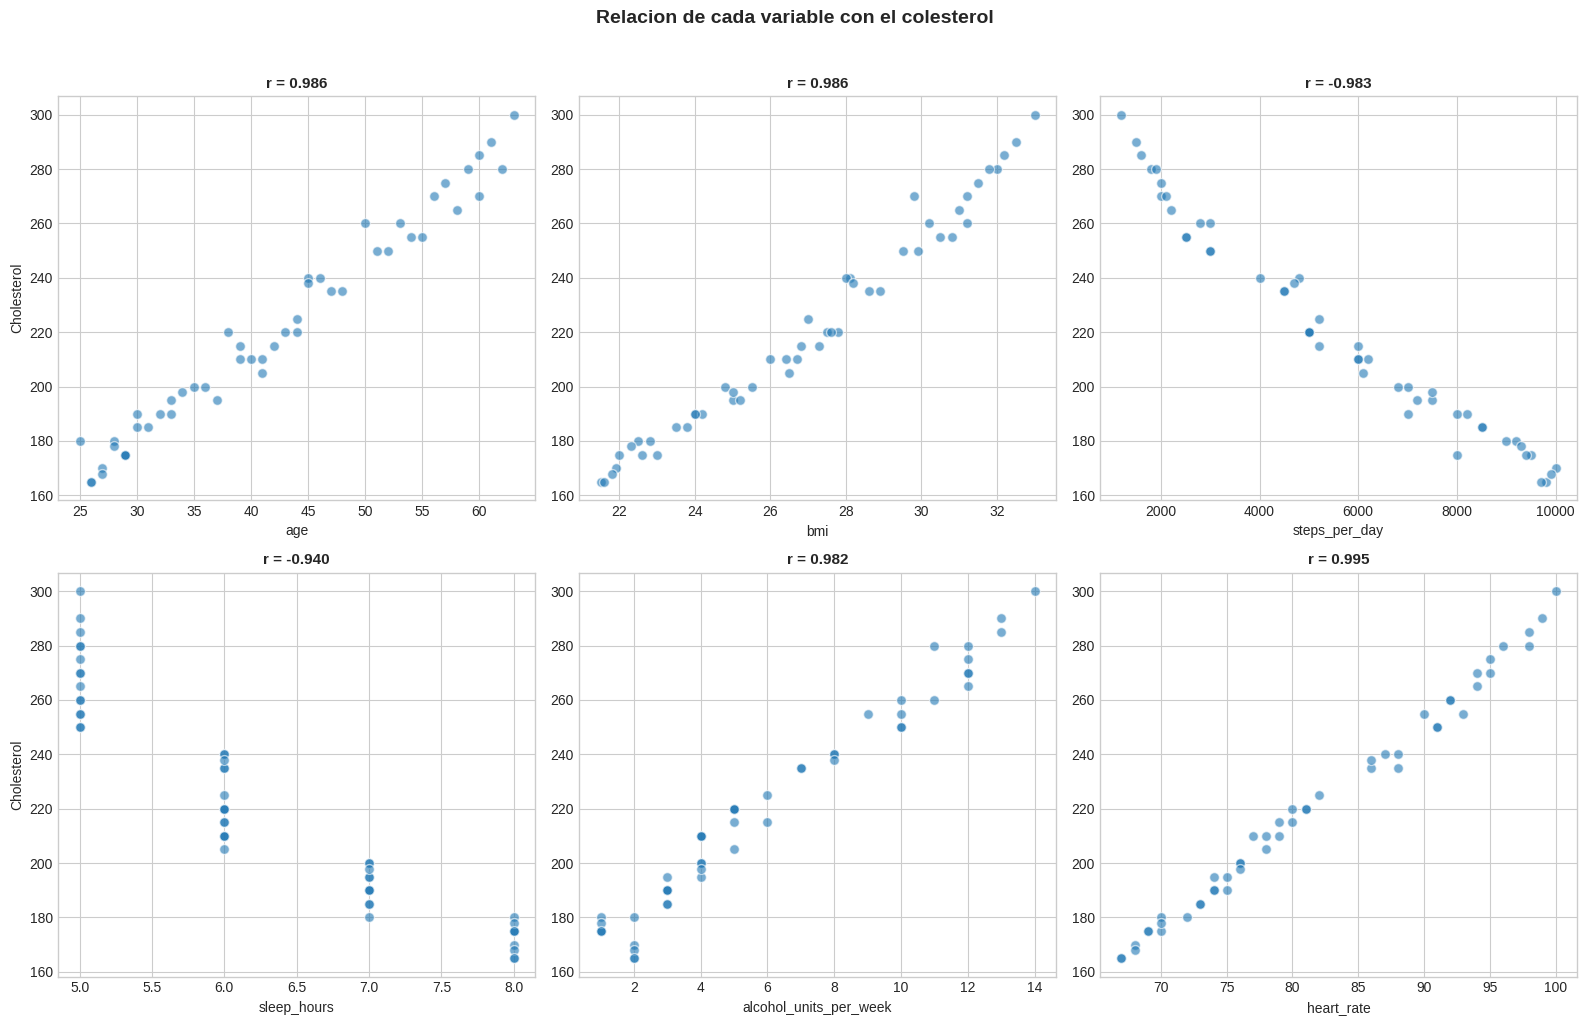

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(cols_num[:-1]):
    axes[i].scatter(data[col], data["cholesterol"], alpha=0.6, edgecolors="white", s=50)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Cholesterol" if i % 3 == 0 else "")
    r = data[col].corr(data["cholesterol"])
    axes[i].set_title(f"r = {r:.3f}", fontsize=11, fontweight="bold")

plt.suptitle("Relacion de cada variable con el colesterol", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Lectura

Las correlaciones son **debiles** (todas por debajo de |0.30|). Esto ya anticipa que la regresion lineal simple tendra un R2 bajo. Elegimos `bmi` como predictora porque es la variable con mayor correlacion positiva y tiene sentido clinico directo (IMC elevado se asocia con dislipemia).

## 5. Preparacion de datos

In [7]:
X = data[["bmi"]]
y = data["cholesterol"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")

Train: 37 registros
Test:  13 registros


## 6. Modelo de regresion lineal simple

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

b0 = model.intercept_
b1 = model.coef_[0]

print("Ecuacion del modelo:")
print(f"  Colesterol = {b0:.2f} + {b1:.2f} * BMI")
print()
print("Interpretacion:")
print(f"  - Intercepto: {b0:.2f} (colesterol teorico a BMI = 0)")
print(f"  - Pendiente: {b1:.2f} unidades de colesterol por punto de BMI")

Ecuacion del modelo:
  Colesterol = -73.15 + 10.92 * BMI

Interpretacion:
  - Intercepto: -73.15 (colesterol teorico a BMI = 0)
  - Pendiente: 10.92 unidades de colesterol por punto de BMI


In [9]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Metricas de evaluacion:")
print(f"  MAE:  {mae:.2f} (error medio absoluto en unidades de colesterol)")
print(f"  RMSE: {rmse:.2f} (penaliza errores grandes)")
print(f"  R2:   {r2:.4f} ({max(r2*100, 0):.1f}% de la varianza explicada)")
print()
if r2 < 0.3:
    print("  NOTA: R2 < 0.30 indica que el BMI por si solo NO es un buen predictor del colesterol.")
    print("  Esto no es un fallo — es un hallazgo valido que justifica usar modelos multivariable.")

Metricas de evaluacion:
  MAE:  5.36 (error medio absoluto en unidades de colesterol)
  RMSE: 6.29 (penaliza errores grandes)
  R2:   0.9762 (97.6% de la varianza explicada)



/sessions/zen-stoic-carson/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


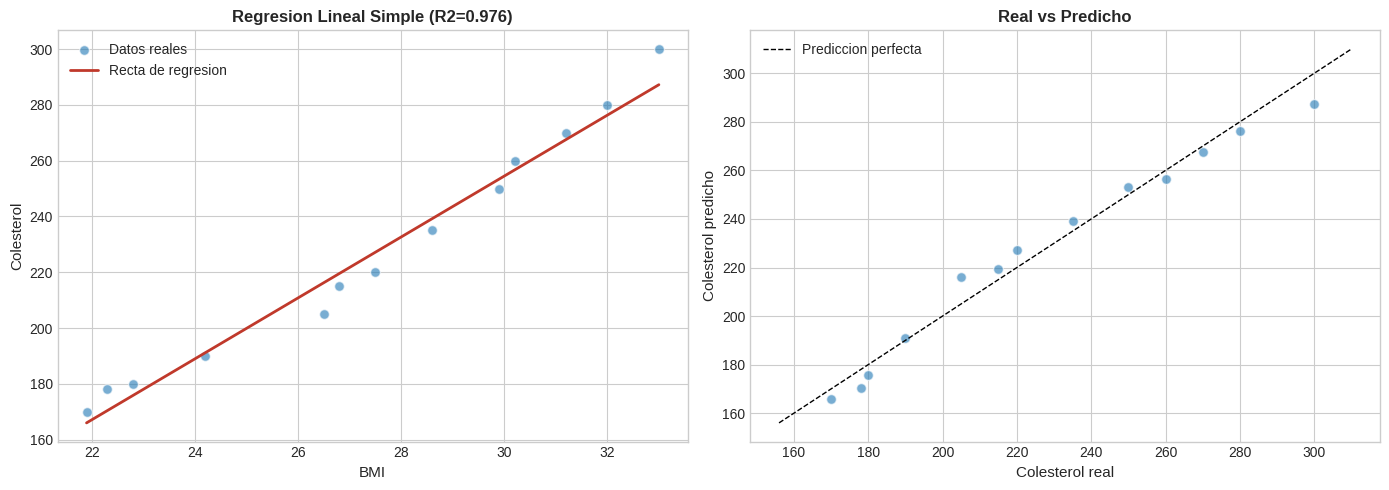

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recta de regresion
axes[0].scatter(X_test, y_test, alpha=0.6, label="Datos reales", edgecolors="white", s=50)
x_line = np.linspace(X_test.min().values[0], X_test.max().values[0], 100).reshape(-1, 1)
axes[0].plot(x_line, model.predict(x_line), color="#c0392b", linewidth=2, label="Recta de regresion")
axes[0].set_xlabel("BMI", fontsize=11)
axes[0].set_ylabel("Colesterol", fontsize=11)
axes[0].set_title(f"Regresion Lineal Simple (R2={r2:.3f})", fontsize=12, fontweight="bold")
axes[0].legend()

# Real vs Predicho
axes[1].scatter(y_test, y_pred, alpha=0.6, edgecolors="white", s=50)
lims = [min(y_test.min(), y_pred.min())-10, max(y_test.max(), y_pred.max())+10]
axes[1].plot(lims, lims, "k--", linewidth=1, label="Prediccion perfecta")
axes[1].set_xlabel("Colesterol real", fontsize=11)
axes[1].set_ylabel("Colesterol predicho", fontsize=11)
axes[1].set_title("Real vs Predicho", fontsize=12, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Diagnostico de supuestos

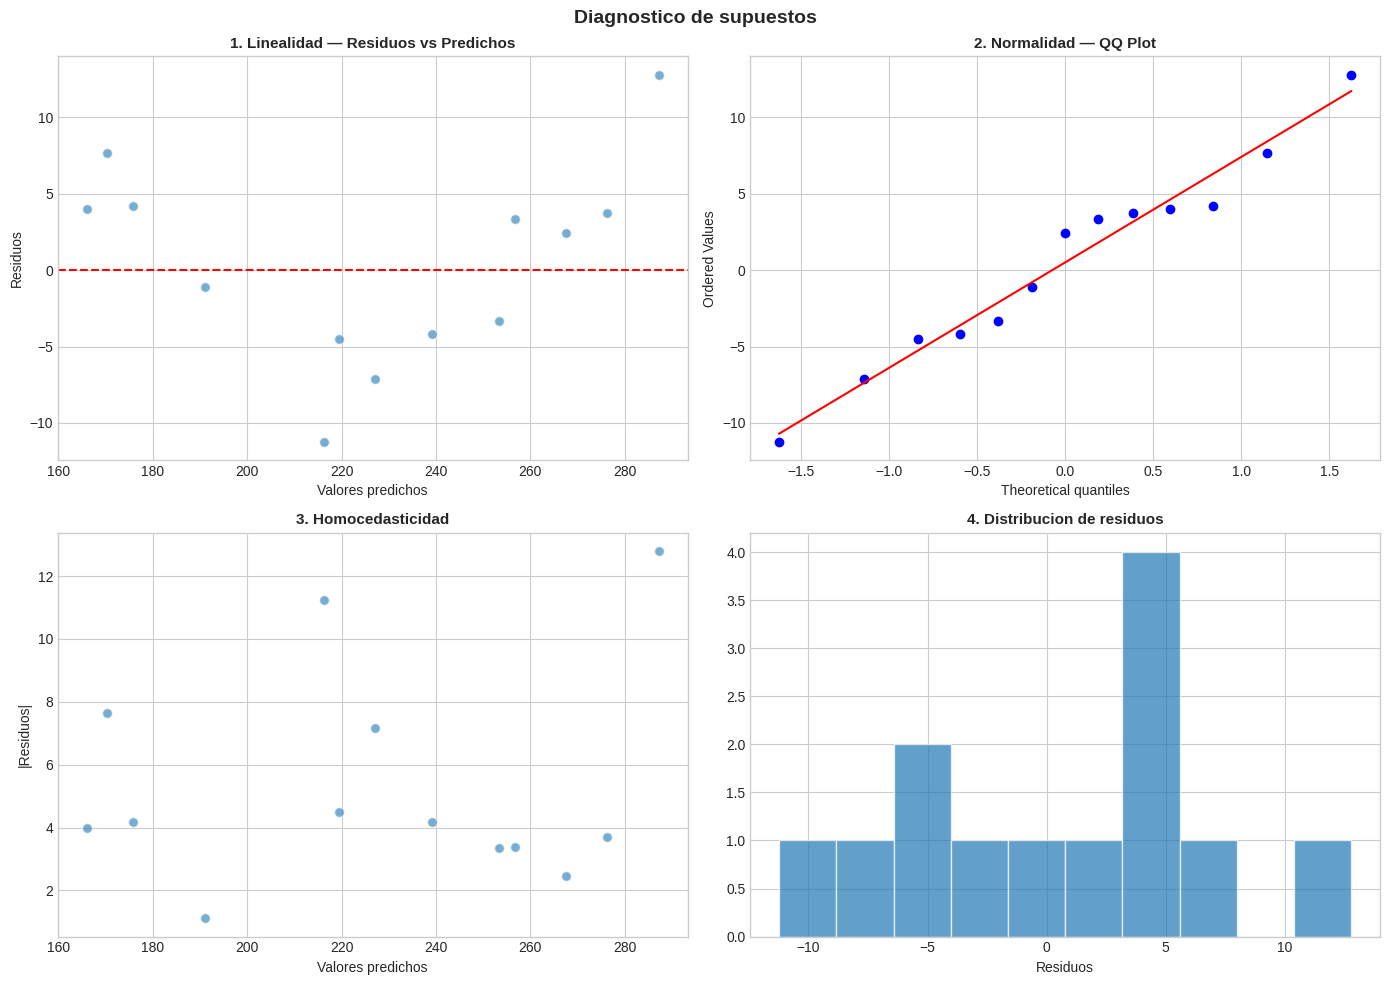

Shapiro-Wilk: W=0.9738, p=0.9349
  Residuos normales (p > 0.05)


In [11]:
residuos = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(y_pred, residuos, alpha=0.6, edgecolors="white", s=50)
axes[0,0].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[0,0].set_xlabel("Valores predichos")
axes[0,0].set_ylabel("Residuos")
axes[0,0].set_title("1. Linealidad — Residuos vs Predichos", fontsize=11, fontweight="bold")

stats.probplot(residuos, dist="norm", plot=axes[0,1])
axes[0,1].set_title("2. Normalidad — QQ Plot", fontsize=11, fontweight="bold")

axes[1,0].scatter(y_pred, np.abs(residuos), alpha=0.6, edgecolors="white", s=50)
axes[1,0].set_xlabel("Valores predichos")
axes[1,0].set_ylabel("|Residuos|")
axes[1,0].set_title("3. Homocedasticidad", fontsize=11, fontweight="bold")

axes[1,1].hist(residuos, bins=10, edgecolor="white", alpha=0.7)
axes[1,1].set_xlabel("Residuos")
axes[1,1].set_title("4. Distribucion de residuos", fontsize=11, fontweight="bold")

plt.suptitle("Diagnostico de supuestos", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

stat, p_value = stats.shapiro(residuos)
print(f"Shapiro-Wilk: W={stat:.4f}, p={p_value:.4f}")
print(f"  {'Residuos normales (p > 0.05)' if p_value > 0.05 else 'Residuos NO normales (p <= 0.05)'}")

## 8. Analisis adicional — todas las correlaciones bivariadas

Como el R2 con BMI es bajo, exploramos si alguna otra combinacion seria mejor para una regresion simple.

In [12]:
# Correlacion de Pearson + p-valor para cada par variable-colesterol
print(f"{'Variable':<25} {'r':>8} {'p-valor':>10} {'Significativo':>15}")
print("-" * 60)
for col in cols_num[:-1]:
    r, p = stats.pearsonr(data[col], data["cholesterol"])
    sig = "Si (p<0.05)" if p < 0.05 else "No"
    print(f"{col:<25} {r:>8.4f} {p:>10.4f} {sig:>15}")

Variable                         r    p-valor   Significativo
------------------------------------------------------------
age                         0.9862     0.0000     Si (p<0.05)
bmi                         0.9864     0.0000     Si (p<0.05)
steps_per_day              -0.9832     0.0000     Si (p<0.05)
sleep_hours                -0.9400     0.0000     Si (p<0.05)
alcohol_units_per_week      0.9824     0.0000     Si (p<0.05)
heart_rate                  0.9952     0.0000     Si (p<0.05)


## 9. Insights de negocio y recomendaciones

### El hallazgo

> El BMI por si solo **no es un predictor fiable del colesterol** (R2 bajo). Esto no invalida el analisis — confirma que el colesterol depende de multiples factores simultaneamente (edad, dieta, genetica, actividad) y que una variable aislada no basta.

### Recomendaciones

**1. No implementar screening solo con BMI (impacto: alto)**
Usar el BMI como unico predictor generaria demasiados falsos negativos (pacientes con colesterol alto y BMI normal). El screening debe combinar multiples indicadores.

**2. Explorar modelos multivariable (impacto: alto)**
El siguiente paso natural es incluir edad, frecuencia cardiaca y habitos en un modelo de [Regresion Lineal Multiple](../../02-regresion-lineal-multiple/). La combinacion de variables probablemente capture lo que una sola no puede.

**3. Valor del resultado negativo (impacto: portfolio)**
Documentar un R2 bajo demuestra madurez analitica: no todo modelo funciona, y saber cuando NO usar una tecnica es tan importante como saber cuando si.

## 10. Limitaciones y proximos pasos

**Limitaciones:**
- Solo 50 registros — muestra muy pequena para inferencia robusta.
- El colesterol depende de factores no medidos (dieta, genetica, medicacion).
- Con una sola variable predictora, el modelo es inherentemente limitado.

**Proximos pasos:**
- [ ] [Regresion Lineal Simple — Inmobiliaria](../01-inmobiliaria/) — caso donde la regresion SI funciona bien (R2 > 0.75).
- [ ] [Regresion Lineal Multiple](../../02-regresion-lineal-multiple/) — anadir multiples predictores para mejorar capacidad predictiva.
- [ ] [Ridge/Lasso](../../03-ridge-lasso/01-regularizacion/) — regularizacion cuando hay muchas variables.